In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

df = pd.read_csv("../data/raw_aqi_data.csv", parse_dates=["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)

print(df.shape)
df.head()

(722, 11)


,datetime,aqi_epa,openweather_aqi,co,no,no2,o3,so2,pm2_5,pm10,nh3
0,2026-07-11 18:00:00,117,4,91.23,0.02,0.31,80.22,1.03,40.25,186.37,1.64
1,2026-07-11 19:00:00,121,4,97.42,0.01,0.46,82.52,1.19,42.69,196.22,1.91
2,2026-07-11 20:00:00,129,5,104.29,0.00,0.55,86.24,1.43,46.27,212.08,2.08
3,2026-07-11 21:00:00,146,5,109.05,0.00,0.58,89.67,1.79,52.31,245.61,2.08
4,2026-07-11 22:00:00,177,5,112.26,0.00,0.62,92.61,2.32,62.31,307.32,2.04


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 722 entries, 0 to 721
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   datetime         722 non-null    datetime64[ns]
 1   aqi_epa          722 non-null    int64         
 2   openweather_aqi  722 non-null    int64         
 3   co               722 non-null    float64       
 4   no               722 non-null    float64       
 5   no2              722 non-null    float64       
 6   o3               722 non-null    float64       
 7   so2              722 non-null    float64       
 8   pm2_5            722 non-null    float64       
 9   pm10             722 non-null    float64       
 10  nh3              722 non-null    float64       
dtypes: datetime64[ns](1), float64(8), int64(2)
memory usage: 62.2 KB


,datetime,aqi_epa,openweather_aqi,co,no,no2,o3,so2,pm2_5,pm10,nh3
count,722,722.000000,722.000000,722.000000,722.000000,722.000000,722.000000,722.000000,722.000000,722.000000,722.000000
mean,2026-07-26 18:29:45.531855872,101.907202,3.801939,201.389197,0.038532,1.074169,73.392645,1.197341,34.714598,131.448920,2.555055
min,2026-07-11 18:00:00,55.000000,2.000000,81.130000,0.000000,0.160000,40.070000,0.140000,13.010000,28.270000,0.000000
25%,2026-07-19 06:15:00,79.000000,3.000000,103.070000,0.000000,0.562500,60.510000,0.542500,24.772500,87.977500,0.872500
50%,2026-07-26 18:30:00,96.000000,4.000000,126.895000,0.010000,0.955000,69.280000,0.850000,33.160000,123.195000,2.200000
75%,2026-08-03 06:45:00,124.000000,4.000000,298.657500,0.050000,1.420000,82.765000,1.567500,44.300000,164.820000,3.447500
max,2026-08-10 17:09:40,208.000000,5.000000,734.290000,0.340000,4.610000,137.460000,4.730000,81.740000,359.620000,12.920000
std,NaN,29.215465,0.681311,147.602554,0.059987,0.701801,19.871714,0.916785,12.596087,57.138907,2.220087


In [4]:
df.isnull().sum()
df["datetime"].duplicated().sum()

0

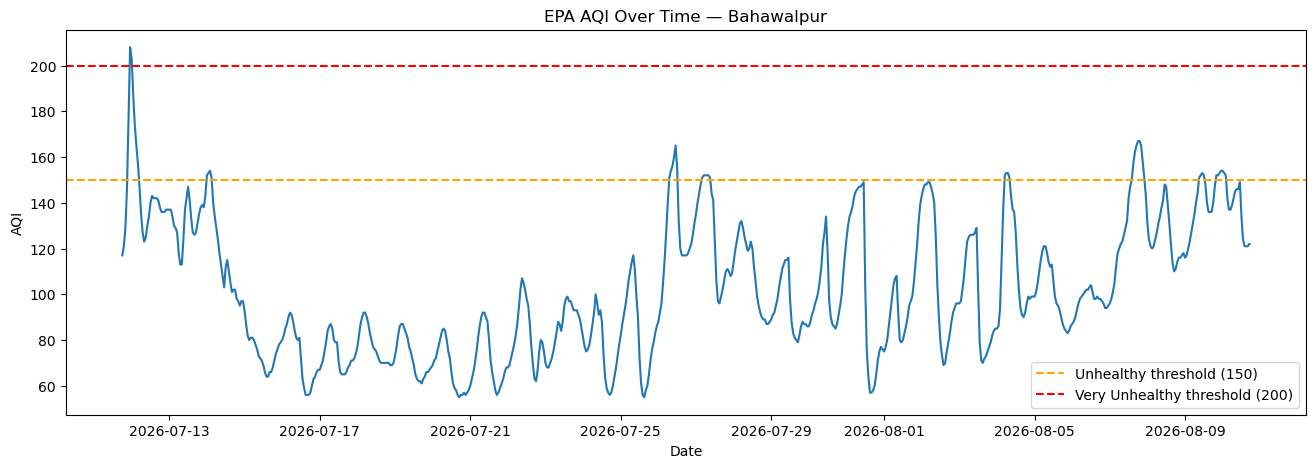

In [5]:
plt.figure(figsize=(16, 5))
plt.plot(df["datetime"], df["aqi_epa"])
plt.axhline(150, color="orange", linestyle="--", label="Unhealthy threshold (150)")
plt.axhline(200, color="red", linestyle="--", label="Very Unhealthy threshold (200)")
plt.title("EPA AQI Over Time — Bahawalpur")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.legend()
plt.show()

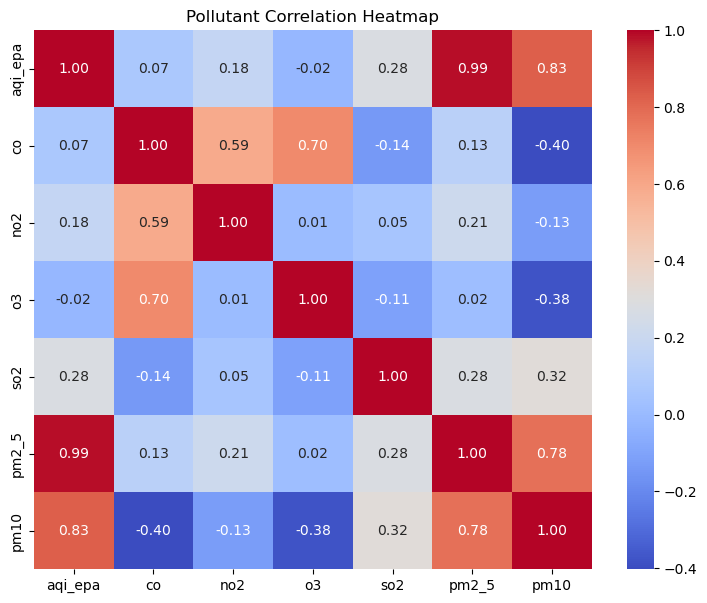

In [6]:
plt.figure(figsize=(9, 7))
sns.heatmap(df[["aqi_epa", "co", "no2", "o3", "so2", "pm2_5", "pm10"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Pollutant Correlation Heatmap")
plt.show()

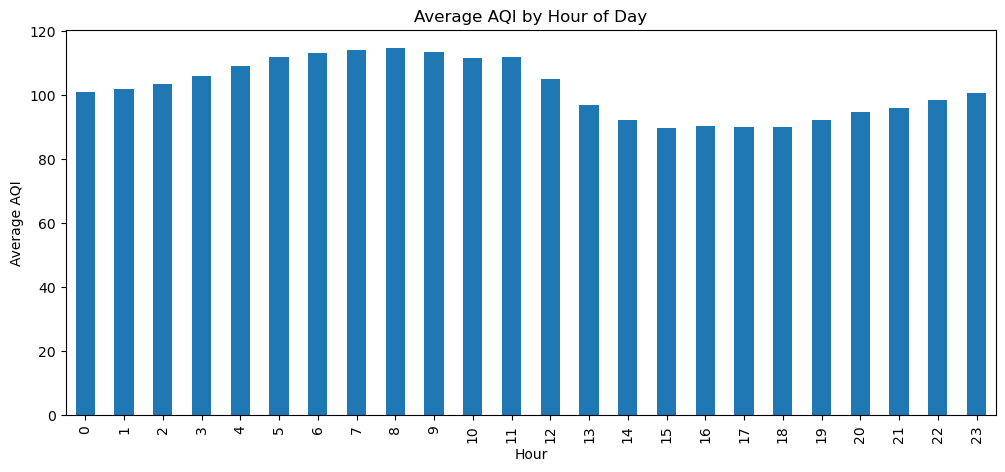

In [7]:
df["hour"] = df["datetime"].dt.hour
hourly_avg = df.groupby("hour")["aqi_epa"].mean()

plt.figure(figsize=(12, 5))
hourly_avg.plot(kind="bar")
plt.title("Average AQI by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Average AQI")
plt.show()